## Explain Node Representations using TACENR explainer

In [1]:
import torch
from torch_geometric.nn import Node2Vec, GCNConv, GATConv, GAE
import networkx as nx
import os 
import numpy as np
from tqdm import tqdm
import sys
sys.path.append(os.path.join(os.getcwd(), 'src'))
from graphLoader import GraphLoader
import random
import pandas as pd
import os, json, numpy as np, torch, torch.nn.functional as F
from torch_geometric.nn import SAGEConv
from explainer import Explainer
import json
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

In [2]:
def compute_structural_node_features(G, node):
    degree = G.degree[node]
    avg_neighbor_degree_dict = nx.average_neighbor_degree(G, nodes=[node]).get(node, 0)
    clustering_coefficient = nx.clustering(G, node)
    node_triangles = nx.triangles(G)[node]
    ppr = nx.pagerank(G, alpha=0.85, personalization={node: 1})
    ppr_std = np.std(list(ppr.values()))

    neighbors = list(G.neighbors(node))
    avg_neighbor_clustering = np.mean([nx.clustering(G, n) for n in neighbors]) if neighbors else 0

    return np.array([
        degree,
        avg_neighbor_degree_dict,
        clustering_coefficient,
        node_triangles,
        ppr_std,
        avg_neighbor_clustering
    ])

def get_node_features(G, node_attrs, dataset_name, save_dir="Node_Features"):
    os.makedirs(save_dir, exist_ok=True)
    save_path = os.path.join(save_dir, f"{dataset_name}_features.npy")
    columns_path = os.path.join(save_dir, f"{dataset_name}_columns.txt")
    
    
    if os.path.exists(save_path) and os.path.exists(columns_path):
        features = np.load(save_path)
        with open(columns_path, "r") as f:
            columns = f.read().strip().split("\n")
        node_ids = sorted(G.nodes())
        return pd.DataFrame(features, index=node_ids, columns=columns)

  
    feature_columns = [
        "Degree",
        "Avg Neighbor Degree",
        "Clustering Coefficient",
        "Node Triangles",
        "Personalized Pagerank Std",
        "Avg Neighbor Clustering",
    ]
    attr_columns = [f"{str(i)}" for i in range(node_attrs.shape[1])]
    all_columns = feature_columns + attr_columns

    features = []
    node_ids = sorted(G.nodes())

    for node in tqdm(node_ids, desc="Computing node features"):
        struct = compute_structural_node_features(G, node)
        attr = node_attrs[node]
        combined = np.concatenate([struct, attr])
        features.append(combined)

    features = np.array(features)
    np.save(save_path, features)

    with open(columns_path, "w") as f:
        f.write("\n".join(all_columns))

    return pd.DataFrame(features, index=node_ids, columns=all_columns)

In [3]:
class GCNEncoder(torch.nn.Module):
    def __init__(self, in_channels, out_channels, hidden_mul=2, dropout=0.0, cached=True):
        super().__init__()
        hidden = hidden_mul * out_channels
        self.conv1 = GCNConv(in_channels, hidden, cached=cached)
        self.conv2 = GCNConv(hidden, out_channels, cached=cached)
        self.dropout = dropout
    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index); x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = self.conv2(x, edge_index); return x

class SAGEEncoder(torch.nn.Module):
    def __init__(self, in_channels, out_channels, hidden_mul=2, dropout=0.0, aggr="mean"):
        super().__init__()
        hidden = hidden_mul * out_channels
        self.conv1 = SAGEConv(in_channels, hidden, aggr=aggr)
        self.conv2 = SAGEConv(hidden, out_channels, aggr=aggr)
        self.dropout = dropout
    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index); x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = self.conv2(x, edge_index); return x
    
class GATEncoder(torch.nn.Module):
    def __init__(self, in_channels, out_channels, heads=8, hidden_mul=2, dropout=0.0):
        super().__init__()
        hidden = hidden_mul * out_channels
        self.gat1 = GATConv(in_channels, hidden, heads=heads, concat=True, dropout=dropout)
        self.gat2 = GATConv(hidden * heads, out_channels, heads=1, concat=False, dropout=dropout)
        self.dropout = dropout

    def forward(self, x, edge_index):
        x = self.gat1(x, edge_index)
        x = F.elu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = self.gat2(x, edge_index)
        return x

    
EMB_PATH = {
    "Node2Vec":  "./unsupervised_embeddings/{ds}/node2vec_best.npy",
    "GCN":       "./unsupervised_embeddings/{ds}/gcn_gae_best.npy",
    "GraphSAGE": "./unsupervised_embeddings/{ds}/graphsage_gae_best.npy",
    "GAT":       "./unsupervised_embeddings/{ds}/gat_gae_best.npy",
}
MODEL_PATH = {
    "Node2Vec":  "./unsupervised_embeddings/{ds}/node2vec_best.pth",
    "GCN":       "./unsupervised_embeddings/{ds}/gcn_gae_best.pth",
    "GraphSAGE": "./unsupervised_embeddings/{ds}/graphsage_gae_best.pth",
    "GAT":       "./unsupervised_embeddings/{ds}/gat_gae_best.pth",
}

SUMMARY_CANDIDATES = {
    "Node2Vec":  ["./unsupervised_embeddings/{ds}/Node2Vec_summary.json", "./saved_models/{ds}/summary.json"],
    "GCN":       ["./unsupervised_embeddings/{ds}/GCN_summary.json", "./unsupervised_embeddings/{ds}/summary.json"],
    "GraphSAGE": ["./unsupervised_embeddings/{ds}/GraphSAGE_summary.json", "./unsupervised_embeddings/{ds}/summary.json"],
    "GAT":       ["./unsupervised_embeddings/{ds}/GAT_summary.json",
                  "./unsupervised_embeddings/{ds}/summary.json"],
}

def _load_summary_dict(method, ds):
    for tmpl in SUMMARY_CANDIDATES.get(method, []):
        p = tmpl.format(ds=ds)
        if os.path.exists(p):
            try:
                with open(p, "r") as f: return json.load(f)
            except Exception:
                pass
    return {}  
def _read_role2vec_csv(path, expected_n=None):
    
    df = pd.read_csv(path)
    if 'id' not in df.columns:
        raise ValueError("CSV must have an 'id' column as the first column.")

    ids = df['id'].to_numpy()
    if not np.allclose(ids, np.round(ids)):
        raise ValueError("Found non-integer ids in 'id' column.")
    ids = ids.astype(int)

    X = df.drop(columns=['id']).to_numpy(dtype=np.float32)
    N_csv, D = X.shape

    
    if expected_n is None:
        expected_n = int(ids.max()) + 1
    Z = np.zeros((expected_n, D), dtype=np.float32)
    uniq, counts = np.unique(ids, return_counts=True)
    if (counts > 1).any():
        dups = uniq[counts > 1]
        raise ValueError(f"Duplicate ids found in CSV: {dups[:10]}...")
    in_range = (ids >= 0) & (ids < expected_n)
    if not np.all(in_range):
        bad = ids[~in_range][:10]
        raise ValueError(f"id(s) out of range for expected_n={expected_n}: {bad}")

    Z[ids[in_range]] = X[in_range]

   
    missing = set(range(expected_n)) - set(ids[in_range])
    if missing:
        print(f"[Role2Vec CSV] Warning: {len(missing)} node ids missing; their rows are zeros.")

    return Z
def load_model_and_embeddings(method: str, dataset: str, data, device=None):
    
    assert method in EMB_PATH, f"Unknown method: {method}"
    emb_path = EMB_PATH[method].format(ds=dataset)
    mdl_path = MODEL_PATH[method].format(ds=dataset)

    if not os.path.exists(emb_path):
        raise FileNotFoundError(f"Embeddings not found: {emb_path}")
    Z = np.load(emb_path)

    if device is None:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    if getattr(data, "x", None) is None:
        x_dim = data.num_nodes  # 
    else:
        x_dim = int(data.x.size(-1))

    out_dim = Z.shape[1]
    summary = _load_summary_dict(method, dataset)
    cfg = summary.get("config", {}) if isinstance(summary, dict) else {}

    if method == "Node2Vec":
        n, d = Z.shape  
        edge_index = data.edge_index
        if edge_index.numel() > 0 and int(edge_index.max()) >= n:
            edge_index = torch.empty((2, 0), dtype=torch.long)

        model = Node2Vec(
            edge_index,
            num_nodes=int(n),
            embedding_dim=int(d),
            walk_length=1, context_size=1, num_negative_samples=1,
            p=1.0, q=1.0, walks_per_node=1, sparse=True
        ).to(device)
        if os.path.exists(mdl_path):
            sd = torch.load(mdl_path, map_location=device)
            if sd["embedding.weight"].shape == (n, d):
                model.load_state_dict(sd)
            else:
                with torch.no_grad():
                    model.embedding.weight.data = torch.from_numpy(Z).to(device)
        else:
            with torch.no_grad():
                model.embedding.weight.data = torch.from_numpy(Z).to(device)

        model.eval()
        return model, Z

    elif method == "GCN":
        hidden_mul = int(cfg.get("hidden_mul", 2))
        dropout    = float(cfg.get("dropout", 0.0))
        enc = GCNEncoder(x_dim, out_dim, hidden_mul=hidden_mul, dropout=dropout, cached=True)
        model = GAE(enc).to(device)
        if os.path.exists(mdl_path):
            model.load_state_dict(torch.load(mdl_path, map_location=device))
        model.eval()
        return model, Z

    elif method == "GraphSAGE":
        hidden_mul = int(cfg.get("hidden_mul", 2))
        dropout    = float(cfg.get("dropout", 0.0))
        enc = SAGEEncoder(x_dim, out_dim, hidden_mul=hidden_mul, dropout=dropout)
        model = GAE(enc).to(device)
        if os.path.exists(mdl_path):
            model.load_state_dict(torch.load(mdl_path, map_location=device))
        model.eval()
        return model, Z
    if method == "GAT":
        hidden_mul = int(cfg.get("hidden_mul", 2))
        dropout    = float(cfg.get("dropout", 0.0))
        heads_cfg  = cfg.get("heads", None)

        sd = None
        if os.path.exists(mdl_path):
            sd = torch.load(mdl_path, map_location=device)

        heads = int(heads_cfg) if heads_cfg is not None else 8
        per_head = None  

        if sd is not None:
            try:
                att_src = sd["encoder.gat1.att_src"]            
                lin_src_w = sd["encoder.gat1.lin_src.weight"]   
                heads = int(att_src.shape[1])
                total_hidden = int(lin_src_w.shape[0])          
                per_head = max(1, total_hidden // heads)
            except KeyError:
                pass  
        if per_head is None:
            total_hidden = hidden_mul * out_dim
            per_head = max(1, total_hidden // heads)

        class GATEncoderRobust(torch.nn.Module):
            def __init__(self, in_channels, out_channels, heads, per_head, dropout):
                super().__init__()
                self.gat1 = GATConv(in_channels, per_head, heads=heads, concat=True, dropout=dropout)
                self.gat2 = GATConv(per_head * heads, out_channels, heads=1, concat=False, dropout=dropout)
                self.dropout = dropout
            def forward(self, x, edge_index):
                x = F.elu(self.gat1(x, edge_index))
                x = F.dropout(x, p=self.dropout, training=self.training)
                x = self.gat2(x, edge_index)
                return x

        enc = GATEncoderRobust(x_dim, out_dim, heads=heads, per_head=per_head, dropout=dropout)
        model = GAE(enc).to(device)

        if sd is not None:
            try:
                model.load_state_dict(sd, strict=True)
            except RuntimeError as e:
                print("Strict load failed for GAT; falling back to non-strict:", e)
                missing, unexpected = model.load_state_dict(sd, strict=False)
                print("Missing keys:", missing)
                print("Unexpected keys:", unexpected)

        model.eval()
        return model, Z
    else:
        raise ValueError(f"Unsupported method: {method}")

In [4]:
datasets = ['Cora'] # 'CiteSeer', 'Pubmed','PPI'
embedding_methods = ["Node2Vec"]#, "Role2Vec", "GCN", "GraphSAGE", "GAT"]
 
ratios_to_try = [
    (0.8, 0.2),  
#    (0.6, 0.4),   
#    (0.4, 0.6),  
#    (0.2, 0.8), 
]

embedding_dimension = 64

importance_results = {}
frequency_results = {}
model_type = "linear" # Other options: lasso, ridge, hsic_lasso
for row, embedding_method in enumerate(embedding_methods):
    for col, graph_dataset_name in enumerate(datasets):
        print(f"\n=== {graph_dataset_name} :: {embedding_method} ===")

        graph_file_path = f'data/{graph_dataset_name}/{graph_dataset_name}_combined.txt'
        graphLoader = GraphLoader(graph_file_path, graph_dataset_name)
        G_nx, G_pyg = graphLoader.load_graph()
        base_dir = os.path.abspath("./unsupervised_embeddings/")  
        embs_path = os.path.join(base_dir, graph_dataset_name, f"{embedding_method}.csv")
         
        if embedding_method == "Role2Vec" or embedding_method == "role2vec_motif" or embedding_method == "role2vec_degree" or embedding_method == "role2vec_wl"or embedding_method == "role2vec":
            embeddings = _read_role2vec_csv(embs_path) 
        else:
            model, embeddings = load_model_and_embeddings(embedding_method, graph_dataset_name, G_pyg)
             
        # Features for explainer
        struct_feature_names = [
            "Proximity","Degree","Avg Neighbor Degree","Clustering Coefficient",
            "Personalized Pagerank","Avg Neighbor Clustering","Node Triangles"
        ]
        
        node_attrs = (G_pyg.x.cpu().numpy() if G_pyg.x is not None
                      else np.eye(G_pyg.num_nodes, dtype=np.float32))
        feature_names = struct_feature_names + [str(i) for i in range(1, node_attrs.shape[1]+1)]
        node_features_df = get_node_features(G_nx, [], dataset_name=graph_dataset_name)

        # Nodes to explain
        frac = 0.10
        N = G_pyg.num_nodes
        num_random_nodes = max(1, min(N, int(round(frac * N))))
        rng = random.Random(42) 
        random_nodes = rng.sample(range(N), num_random_nodes)
        print(f"Number of nodes to explain: {num_random_nodes} / {N} ({frac*100:.0f}%)")

        # Similar/dissimilar configs
        N = G_pyg.num_nodes
        # Explain
        for sim_ratio, dis_ratio in ratios_to_try:
            print(f"\n--- Testing ratio: {int(sim_ratio*100)}% similar, {int(dis_ratio*100)}% dissimilar ---")
            T = min(int(0.10 * N), 300)
            T = max(T, 20)                      
            T = min(T, N - 1)                   
            m = int(T * sim_ratio)              
            n = T - m                           
            
            m = max(1, m)
            n = max(1, n)
            
            print(f"Using m={m}, n={n} (T={T} ~ {100*T/N:.1f}% of {N})")
            all_pprs = []
            mode = "weighted"
            problem = "unsupervised"
            weighting_method="global_variance_only_for_ranking"
            explainer = Explainer(G_nx, G_pyg, node_features_df, all_pprs, random_nodes, feature_names, graph_dataset_name, embedding_method, embeddings, None, explanation_type="global", 
                                node_attributes=True, structural_features = True, problem='regression', model_type=model_type, num_similar=m, num_dissimilar=n, 
                                scale=True, parameter_tuning=True, enable_plots=False, weighting_method=weighting_method, include_target_node_features=False, use_proximity= False)
            
            frequency_df, avg_importances_df, all_importances_df, average_metrics, per_node_metrics_df  = explainer.explain(mode = mode, problem = problem)
            
            results_base_path = (
                f"Results/{problem}/Both_Features/{model_type}/{mode}_{weighting_method}/"
                f"{graph_dataset_name}/{embedding_method}_{embedding_dimension}/"
                f"num_similar_{m}_num_dissimilar_{n}"
            )
            os.makedirs(results_base_path, exist_ok=True)
            with open(os.path.join(results_base_path, f"metrics_{model_type}.json"), "w") as f:
                json.dump(average_metrics, f, indent=4)

            avg_importances_df.to_csv(os.path.join(results_base_path, f"average_importances_{model_type}.csv"), index=False)
            all_importances_df.to_csv(os.path.join(results_base_path, f"all_importances_{model_type}.csv"), index=False)
            frequency_df.to_csv(os.path.join(results_base_path, f"feature_frequencies_{model_type}.csv"), index=False)
            per_node_metrics_df.to_csv(os.path.join(results_base_path, f"per_node_metrics_{model_type}.csv"), index=False)
                


=== Cora :: Node2Vec ===
NetworkX - Number of nodes: 2485
NetworkX - Number of edges: 5069
NetworkX graph is undirected.
NetworkX graph is connected: True
Number of graphs: 6
PyG - Number of features per node: 1433
Number of classes: 7
PyG - Number of nodes: 2485
PyG - Number of edges: 10138
Is undirected: True
PyG - Number of features per node: 1433
Number of nodes to explain: 248 / 2485 (10%)

--- Testing ratio: 80% similar, 20% dissimilar ---
Using m=198, n=50 (T=248 ~ 10.0% of 2485)


Processing nodes: 100%|██████████| 248/248 [10:50<00:00,  2.62s/it]


### Plot feature importances for all datasets and models

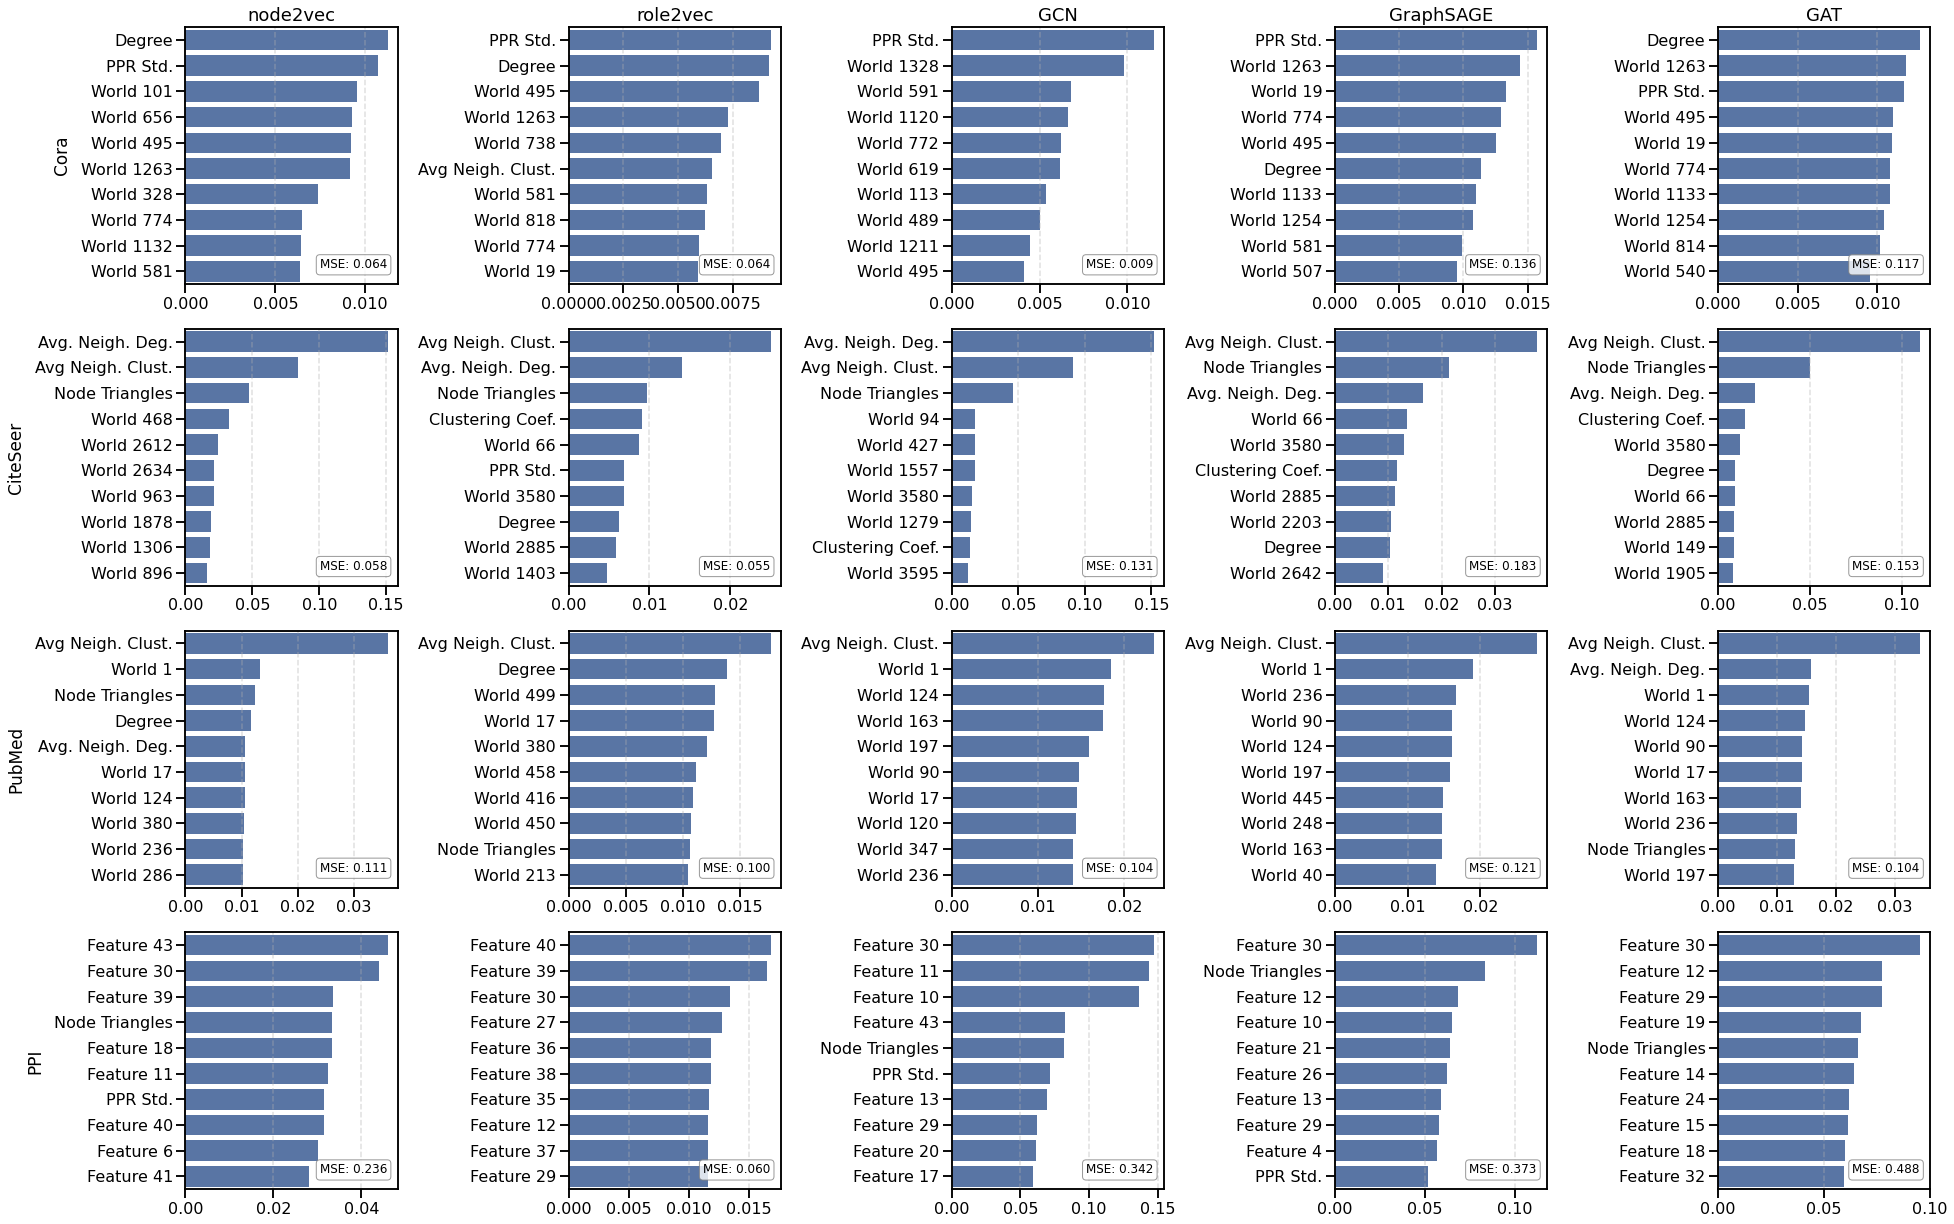

In [ ]:
def plot_feature_importance_barplot_grid(problem,
    datasets, embedding_methods, embedding_dim, mode,
    model_type="linear", save_path="Figures",
    rename_features=None, rename_methods=None
):
    
    sys.stdout = open(os.devnull, "w")
    sns.set_context("talk", font_scale=1.2)
    plt.rcParams.update({'font.size': 16})

    n_rows = len(datasets)             
    n_cols = len(embedding_methods)    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5.5 * n_cols, 4.5 * n_rows), squeeze=False)

    ratios_to_try = [
        (0.8, 0.2),
    ]

    
    for i, dataset in enumerate(datasets):                
        for j, method in enumerate(embedding_methods):    
            ax = axes[i][j]
            try:
                graph_file_path = f'data/{dataset}/{dataset}_combined.txt'
                graphLoader = GraphLoader(graph_file_path, dataset)
                G_nx, G_pyg = graphLoader.load_graph()
                N = G_pyg.num_nodes
            except Exception as e:
                print(f"Error loading graph for {dataset}: {e}")
                ax.axis('off')
                continue
           
            base_sample = min(int(N * 0.10), 300)
            base_sample = max(base_sample, 20)
            best_mse = float("inf")
            best_importances_path = None
       

            for sim_ratio, dis_ratio in ratios_to_try:
                m = int(base_sample * sim_ratio)
                n = base_sample - m
                m, n = max(1, m), max(1, n)

                
                per_node_path = (
                    f"Results/{problem}/Both_Features/{model_type}/{mode}/{dataset}/"
                    f"{method}_{embedding_dim}/num_similar_{m}_num_dissimilar_{n}/per_node_metrics_{model_type}.csv"
                )
                importances_path = (
                    f"Results/{problem}/Both_Features/{model_type}/{mode}/{dataset}/"
                    f"{method}_{embedding_dim}/num_similar_{m}_num_dissimilar_{n}/all_importances_{model_type}.csv"
                )

                if not os.path.exists(per_node_path):
                    continue

                try:
                    df_nodes = pd.read_csv(per_node_path)
                    df_nodes = df_nodes.replace([np.inf, -np.inf], np.nan).dropna(subset=["MSE"])

                    df_filtered = df_nodes[df_nodes["MSE"] < 0.5]
                    if df_filtered.empty:
                        continue

                    mse_score = df_filtered["MSE"].mean()

                except Exception as e:
                    print(f"Error reading per-node metrics for {dataset}, ratio {sim_ratio}: {e}")
                    continue

                if mse_score < best_mse:
                    best_mse = mse_score
                    best_importances_path = importances_path

            if best_importances_path is None:
                print(f"No valid ratio found for {dataset}/{method}")
                ax.axis('off')
                continue

            try:
                df = pd.read_csv(best_importances_path)
            except Exception as e:
                print(f"Error loading best files for {dataset}/{method}: {e}")
                ax.axis('off')
                continue

            mean_abs_importance = (
                df.groupby("Feature")["Importance"]
                .apply(lambda x: x.abs().mean())
                .sort_values(ascending=False)
            )

            top_features = mean_abs_importance.head(10).index.tolist()
            mean_abs_df = mean_abs_importance.loc[top_features].reset_index()
            mean_abs_df.columns = ["Feature", "Mean Absolute Importance"]

            if rename_features:
                mean_abs_df["Feature"] = mean_abs_df["Feature"].apply(
                    lambda x: rename_features.get(x, x)
                )

            if dataset == "PPI":
                mean_abs_df["Feature"] = mean_abs_df["Feature"].apply(
                    lambda x: "Feature " + str(x) if x.isdigit() else x
                )
            else:
                mean_abs_df["Feature"] = mean_abs_df["Feature"].apply(
                    lambda x: "World " + str(x) if x.isdigit() else x
                )

            sns.barplot(
                data=mean_abs_df,
                x="Mean Absolute Importance",
                y="Feature",
                color="#4C72B0",
                ax=ax
            )

            ax.annotate(
                f"MSE: {best_mse:.3f}",
                xy=(0.95, 0.05),
                xycoords='axes fraction',
                ha='right', va='bottom',
                bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='gray', lw=1, alpha=0.8),
                fontsize=12
            )

            if i == 0:
                method_label = rename_methods.get(method, method) if rename_methods else method
                ax.set_title(method_label, fontsize=18)

            if j == 0:
                if dataset.lower() == "pubmed":
                    dataset_label = "PubMed"
                elif dataset.lower() == "ppi":
                    dataset_label = "PPI"
                elif dataset.lower() == "citeseer":
                    dataset_label = "CiteSeer"
                else:
                    dataset_label = dataset.capitalize()

                ax.set_ylabel(dataset_label, fontsize=17, labelpad=10)
            else:
                ax.set_ylabel("")

            ax.set_xlabel("")
            ax.tick_params(axis='x', labelsize=16)
            ax.tick_params(axis='y', labelsize=16)
            ax.grid(True, axis='x', linestyle='--', alpha=0.4)

    plt.tight_layout(rect=[0, 0, 1, 0.96])
    os.makedirs(save_path, exist_ok=True)
    pdf_path = os.path.join(save_path, f"feature_importance_{model_type}_{embedding_dim}.pdf")
    plt.savefig(pdf_path, bbox_inches='tight', format='pdf')
    print(f"Plot saved to: {pdf_path}")
    plt.show()

datasets = ['Cora', "CiteSeer", "Pubmed","PPI"] 
embedding_dim = 64
model_type = "linear"
 
problem = "unsupervised"
mode = "weighted_global_variance_only_for_ranking"
rename_dict = {
    "Clustering Coefficient": "Clustering Coef.",
    "Personalized Pagerank": "PPR Std.",
    "Avg Neighbor Degree": "Avg. Neigh. Deg.",
    "Avg Neighbor Clustering": "Avg Neigh. Clust.",
    "Proximity":"Distance",
    "Personalized Pagerank Std": "PPR Std.",
    "Laplacian Eigenvector": "Laplacian Eig."
}
rename_methods = {
    "role2vec_degree": "role2vec",
    "role2vec_motif": "role2vec",
    "Role2Vec":"role2vec", 
    "Node2Vec":"node2vec"
}

plot_feature_importance_barplot_grid(problem,
    datasets=datasets,
    embedding_methods=["Node2Vec", "Role2Vec", "GCN", "GraphSAGE", "GAT"],
    embedding_dim=embedding_dim,
    mode=mode,
    model_type=model_type,
    rename_features=rename_dict,
    rename_methods=rename_methods,
    save_path="Figures/"   
)
